In [1]:
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision import datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [2]:
batch_size = 128

Loads the test_val_datset, and the test_dataset. This will take a couple of minutes to load

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

training_data = datasets.CIFAR10(
    root= "data", 
    train = True,
    download=True,
    transform=transform
)

testing_data = datasets.CIFAR10(
    root= "data", 
    train = False,
    download=True,
    transform=transform
)



In [17]:
train_val_amt = int(len(training_data) * 0.75)
validation_set = int(len(training_data) - train_val_amt)

print(train_val_amt, validation_set)

train_dataset, validation_dataset = random_split(training_data, [train_val_amt, validation_set], generator=torch.Generator().manual_seed(1234))

37500 12500


In [18]:
train_data_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
testing_data_loader = DataLoader(testing_data, batch_size = batch_size, shuffle = True)

Prints the dataset numbers and percentage of training and validation data.

In [26]:
print(f"Training Data Total: {len(train_dataset)}, {len(train_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Validation Data Total: {len(validation_dataset)}, {len(validation_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Testing Data total:", len(testing_data))


Training Data Total: 37500, 0.75
Validation Data Total: 12500, 0.25
Testing Data total: 10000


tensor([[[0.5098, 0.5529, 0.6118],
         [0.5098, 0.5529, 0.6078],
         [0.5137, 0.5569, 0.6118],
         ...,
         [0.6157, 0.6196, 0.6980],
         [0.6118, 0.6235, 0.6980],
         [0.6000, 0.6118, 0.6863]],

        [[0.5294, 0.5686, 0.6196],
         [0.5216, 0.5608, 0.6118],
         [0.5294, 0.5647, 0.6196],
         ...,
         [0.6078, 0.6157, 0.6902],
         [0.5961, 0.6078, 0.6824],
         [0.5765, 0.5882, 0.6627]],

        [[0.5333, 0.5686, 0.6196],
         [0.5255, 0.5608, 0.6078],
         [0.5373, 0.5686, 0.6157],
         ...,
         [0.5882, 0.6039, 0.6784],
         [0.5882, 0.6000, 0.6745],
         [0.5922, 0.6039, 0.6784]],

        ...,

        [[0.5294, 0.5451, 0.6039],
         [0.5725, 0.5843, 0.6471],
         [0.5725, 0.6039, 0.6706],
         ...,
         [0.6392, 0.6431, 0.7216],
         [0.6431, 0.6471, 0.7294],
         [0.6353, 0.6392, 0.7216]],

        [[0.5412, 0.5647, 0.6196],
         [0.5529, 0.5765, 0.6314],
         [0.

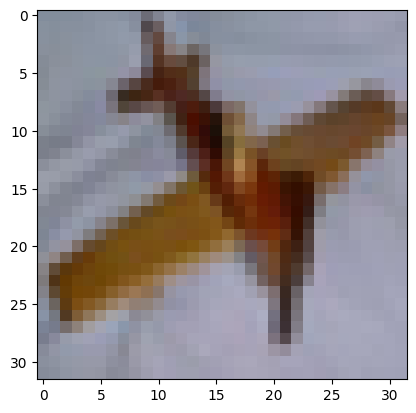

In [29]:
classes = ["Airplane", "Automabile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]
training_iter = iter(train_data_loader)

data_obj, label = next(training_iter)
data_obj = data_obj[0]
data_obj = data_obj * 0.5 + 0.5
data_obj = data_obj.permute(1, 2, 0)
print(data_obj, label)
plt.imshow(data_obj)